Total rasterized windows: 257864


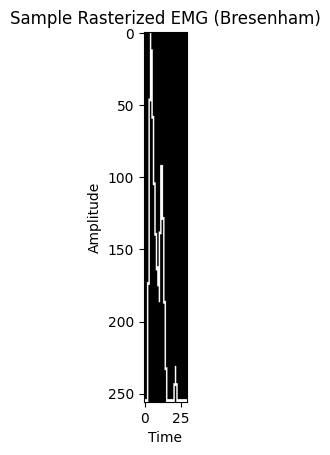

In [4]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
ROOT_DIR = r"C:\Users\ragul\Downloads\Ninapro Dataset"   # change if needed
EXERCISE = "E2"
EMG_CHANNEL = 0
WINDOW_SIZE = 30          # 300 ms @ 100 Hz
OVERLAP = 0.5
AMP_BINS = 256

# =========================
# BRESENHAM LINE ALGORITHM
# =========================
def bresenham_line(x0, y0, x1, y1):
    points = []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy

    while True:
        points.append((x0, y0))
        if x0 == x1 and y0 == y1:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x0 += sx
        if e2 < dx:
            err += dx
            y0 += sy
    return points

# =========================
# WINDOWING FUNCTION
# =========================
def segment_signal(signal, window_size, overlap):
    step = int(window_size * (1 - overlap))
    windows = []
    for i in range(0, len(signal) - window_size, step):
        windows.append(signal[i:i + window_size])
    return windows

# =========================
# SIGNAL → IMAGE (RASTER)
# =========================
def rasterize_signal(signal_window, amp_bins):
    # Per-window normalization
    sig = signal_window - np.min(signal_window)
    sig = sig / (np.max(sig) + 1e-8)

    h = amp_bins
    w = len(sig)
    img = np.zeros((h, w), dtype=np.float32)

    y_vals = (sig * (h - 1)).astype(int)

    for i in range(len(y_vals) - 1):
        pts = bresenham_line(i, y_vals[i], i + 1, y_vals[i + 1])
        for x, y in pts:
            # Line thickness = 3 pixels
            for dy in [-1, 0, 1]:
                yy = h - 1 - y + dy
                if 0 <= yy < h:
                    img[yy, x] = 1.0

    return img


# =========================
# MAIN DATASET LOOP
# =========================
all_images = []
all_labels = []
all_subjects = []

for subject in sorted(os.listdir(ROOT_DIR)):
    subject_path = os.path.join(ROOT_DIR, subject)
    if not os.path.isdir(subject_path):
        continue

    subject_id = subject.lower()   # s1, s2, ...
    mat_file = f"{subject.upper()}_A1_{EXERCISE}.mat"
    mat_path = os.path.join(subject_path, mat_file)

    if not os.path.exists(mat_path):
        continue

    mat = sio.loadmat(mat_path)

    # ---- Ninapro standard keys ----
    emg = mat['emg']                # [samples, channels]
    labels = mat['restimulus'].ravel()

    signal = emg[:, EMG_CHANNEL].astype(np.float32)

    # L2 normalization
    signal = signal / (np.linalg.norm(signal) + 1e-8)

    windows = segment_signal(signal, WINDOW_SIZE, OVERLAP)

    for i, win in enumerate(windows):
        img = rasterize_signal(win, AMP_BINS)
        all_images.append(img)
        all_labels.append(labels[i])
        all_subjects.append(subject)

print("Total rasterized windows:", len(all_images))

# =========================
# VISUAL SANITY CHECK
# =========================
plt.imshow(all_images[0], cmap='gray')
plt.title("Sample Rasterized EMG (Bresenham)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 4060 Laptop GPU


Total rasterized windows (non-rest): 109326
Saved dataset to C:\Users\ragul\Downloads\output_journal


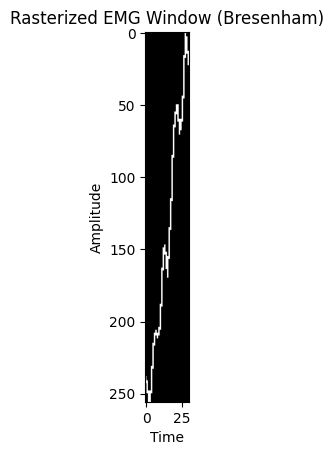

In [1]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from collections import Counter

# =========================================================
# USER SETTINGS
# =========================================================
ROOT_DIR = r"C:\Users\ragul\Downloads\Ninapro Dataset"
EXERCISE = "E2"
EMG_CHANNEL = 0
WINDOW_SIZE = 30        # 300 ms @ 100 Hz
OVERLAP = 0.5
AMP_BINS = 256
SAVE_FILE = "ninapro_DB1_E2_emg_bresenham.npz"

# =========================================================
# BRESENHAM LINE ALGORITHM
# =========================================================
def bresenham_line(x0, y0, x1, y1):
    points = []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy

    while True:
        points.append((x0, y0))
        if x0 == x1 and y0 == y1:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x0 += sx
        if e2 < dx:
            err += dx
            y0 += sy
    return points

# =========================================================
# WINDOWING WITH LABEL MAJORITY VOTE
# =========================================================
def segment_signal_with_labels(signal, labels, window_size, overlap):
    step = int(window_size * (1 - overlap))
    windows, win_labels = [], []

    for i in range(0, len(signal) - window_size, step):
        win_signal = signal[i:i + window_size]
        win_labels_raw = labels[i:i + window_size]

        label_count = Counter(win_labels_raw)
        majority_label = label_count.most_common(1)[0][0]

        # discard rest class
        if majority_label == 0:
            continue

        windows.append(win_signal)
        win_labels.append(majority_label)

    return windows, win_labels

# =========================================================
# SIGNAL → IMAGE (RASTERIZATION)
# =========================================================
def rasterize_signal(signal_window, amp_bins):
    sig = signal_window - np.min(signal_window)
    sig = sig / (np.max(sig) + 1e-8)

    h = amp_bins
    w = len(sig)
    img = np.zeros((h, w), dtype=np.float32)

    y_vals = (sig * (h - 1)).astype(int)

    for i in range(len(y_vals) - 1):
        pts = bresenham_line(i, y_vals[i], i + 1, y_vals[i + 1])
        for x, y in pts:
            for dy in [-1, 0, 1]:  # thickness
                yy = h - 1 - y + dy
                if 0 <= yy < h:
                    img[yy, x] = 1.0

    return img

# =========================================================
# MAIN DATASET LOOP
# =========================================================
all_images = []
all_labels = []
all_subjects = []

for subject in sorted(os.listdir(ROOT_DIR)):
    subject_path = os.path.join(ROOT_DIR, subject)
    if not os.path.isdir(subject_path):
        continue

    subject_id = subject.upper()  # S1, S2, ...
    mat_name = f"{subject_id}_A1_{EXERCISE}.mat"
    mat_path = os.path.join(subject_path, mat_name)

    if not os.path.exists(mat_path):
        continue

    mat = sio.loadmat(mat_path)
    emg = mat['emg']
    labels = mat['restimulus'].ravel()

    # select channel
    signal = emg[:, EMG_CHANNEL].astype(np.float32)

    # EMG energy representation
    signal = np.abs(signal)

    # L2 normalization
    signal = signal / (np.linalg.norm(signal) + 1e-8)

    windows, win_labels = segment_signal_with_labels(
        signal, labels, WINDOW_SIZE, OVERLAP
    )

    for win, lbl in zip(windows, win_labels):
        img = rasterize_signal(win, AMP_BINS)
        all_images.append(img)
        all_labels.append(lbl)
        all_subjects.append(subject)

print("Total rasterized windows (non-rest):", len(all_images))

# =========================================================
# SAVE DATASET
# =========================================================
SAVE_FILE = r"C:\Users\ragul\Downloads\output_journal"
np.savez(
    SAVE_FILE,
    images=np.array(all_images),
    labels=np.array(all_labels),
    subjects=np.array(all_subjects)
)

print(f"Saved dataset to {SAVE_FILE}")

# =========================================================
# VISUAL SANITY CHECK
# =========================================================
plt.imshow(all_images[0], cmap='gray')
plt.title("Rasterized EMG Window (Bresenham)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


['images', 'labels', 'subjects']
(109326, 256, 30)
(109326,)
(109326,)


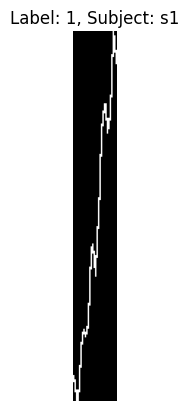

In [7]:
import numpy as np

data = np.load(r"C:\Users\ragul\Downloads\output_journal.npz", allow_pickle=True)
print(data.files)
images = data["images"]
labels = data["labels"]
subjects = data["subjects"]

print(images.shape)
print(labels.shape)
print(subjects.shape)

import matplotlib.pyplot as plt

plt.imshow(images[0], cmap="gray")
plt.title(f"Label: {labels[0]}, Subject: {subjects[0]}")
plt.axis("off")
plt.show()



In [10]:
# =========================================================
# SINGLE-CELL: MULTI-CHANNEL EMG + CNN4-M TRAINING
# =========================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
from collections import Counter

# -------------------------
# LOAD DATA
# -------------------------
data = np.load(r"C:\Users\ragul\Downloads\output_journal.npz", allow_pickle=True)

X = data["images"]      # (N, 10, 256, 30)
y = data["labels"]      # (N,)
subjects = data["subjects"]

print("Data shape:", X.shape)

# -------------------------
# SUBJECT-WISE SPLIT
# -------------------------
train_subjects = [f"s{i}" for i in range(1, 21)]
test_subjects  = [f"s{i}" for i in range(21, 28)]

train_idx = [i for i,s in enumerate(subjects) if s in train_subjects]
test_idx  = [i for i,s in enumerate(subjects) if s in test_subjects]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print("Train samples:", len(y_train))
print("Test samples :", len(y_test))

# -------------------------
# DATASET CLASS
# -------------------------
class EMGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# -------------------------
# CNN4-M STYLE MODEL
# -------------------------
class CNN4M(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # -------- Branches (10-channel input ONLY here) --------
        self.b1 = nn.Sequential(
            nn.Conv2d(10, 16, kernel_size=(5,3), padding=(2,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        self.b2 = nn.Sequential(
            nn.Conv2d(10, 16, kernel_size=(7,3), padding=(3,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        self.b3 = nn.Sequential(
            nn.Conv2d(10, 16, kernel_size=(9,3), padding=(4,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        # -------- Fusion (48-channel input ONLY here) --------
        self.fusion = nn.Sequential(
            nn.Conv2d(48, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )

        # -------- Classifier --------
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x1 = self.b1(x)     # (B,16,H,W)
        x2 = self.b2(x)
        x3 = self.b3(x)

        x = torch.cat([x1, x2, x3], dim=1)  # (B,48,H,W)
        x = self.fusion(x)                  # (B,64,4,4)
        return self.classifier(x)


# -------------------------
# TRAINING SETUP
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_ds = EMGDataset(X_train, y_train)
test_ds  = EMGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

num_classes = len(np.unique(y))
model = CNN4M(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -------------------------
# TRAIN LOOP
# -------------------------
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            out = model(xb)
            preds.extend(out.argmax(1).cpu().numpy())
            true.extend(yb.numpy())

    acc = accuracy_score(true, preds)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Test Accuracy: {acc:.4f}")


Data shape: (109326, 256, 30)
Train samples: 80268
Test samples : 29058
Using device: cuda


RuntimeError: Given groups=1, weight of size [16, 10, 5, 3], expected input[1, 64, 256, 30] to have 10 channels, but got 64 channels instead

In [9]:
model = CNN4M(num_classes).to(device)

dummy = torch.randn(2, 10, 256, 30).to(device)
out = model(dummy)
print("Forward pass OK, output shape:", out.shape)


Forward pass OK, output shape: torch.Size([2, 17])


In [5]:
# =========================================================
# FINAL CLEAN SINGLE-CELL: MULTI-CHANNEL EMG + CNN4-M
# =========================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score

# -------------------------
# CUDA CHECK
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# LOAD DATA
# -------------------------
data = np.load(r"C:\Users\ragul\Downloads\output_journal.npz", allow_pickle=True)

X = data["images"]      # (N, 10, 256, 30)
y = data["labels"]
subjects = data["subjects"]

print("Loaded data shape:", X.shape)

# -------------------------
# SUBJECT-WISE SPLIT
# -------------------------
train_subjects = [f"s{i}" for i in range(1, 21)]
test_subjects  = [f"s{i}" for i in range(21, 28)]

train_idx = [i for i, s in enumerate(subjects) if s in train_subjects]
test_idx  = [i for i, s in enumerate(subjects) if s in test_subjects]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])

# -------------------------
# DATASET
# -------------------------
class EMGDataset(Dataset):
    def __init__(self, X, y):
        X = torch.tensor(X, dtype=torch.float32)

        # If shape is (N, H, W), add channel dimension
        if X.ndim == 3:
            X = X.unsqueeze(1)  # (N, 1, H, W)
            print("Added channel dimension ->", X.shape)

        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = EMGDataset(X_train, y_train)
test_ds  = EMGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

# -------------------------
# CNN4-M MODEL (FIXED)
# -------------------------
class CNN4M(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Branches (ONLY place where 10 channels is expected)
        self.b1 = nn.Sequential(
            nn.Conv2d(10, 16, kernel_size=(5,3), padding=(2,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        self.b2 = nn.Sequential(
            nn.Conv2d(10, 16, kernel_size=(7,3), padding=(3,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        self.b3 = nn.Sequential(
            nn.Conv2d(10, 16, kernel_size=(9,3), padding=(4,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        # Fusion (expects 48 channels ONLY)
        self.fusion = nn.Sequential(
            nn.Conv2d(48, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Sanity checks (CRITICAL)
        assert x.shape[1] == 10, f"Expected 10 channels, got {x.shape[1]}"

        x1 = self.b1(x)
        x2 = self.b2(x)
        x3 = self.b3(x)

        x = torch.cat([x1, x2, x3], dim=1)
        assert x.shape[1] == 48, f"Expected 48 channels, got {x.shape[1]}"

        x = self.fusion(x)
        return self.classifier(x)

# -------------------------
# MODEL INIT + DUMMY TEST
# -------------------------
num_classes = len(np.unique(y))
model = CNN4M(num_classes).to(device)

# Dummy forward pass (THIS PREVENTS YOUR ERROR)
dummy = torch.randn(2, 10, 256, 30).to(device)
out = model(dummy)
print("Dummy forward OK:", out.shape)

# -------------------------
# TRAINING SETUP
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -------------------------
# TRAIN LOOP
# -------------------------
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            out = model(xb)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_true.extend(yb.numpy())

    acc = accuracy_score(all_true, all_preds)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Test Accuracy: {acc:.4f}")


Using device: cuda
Loaded data shape: (109326, 256, 30)
Train samples: 80268
Test samples : 29058
Added channel dimension -> torch.Size([80268, 1, 256, 30])
Added channel dimension -> torch.Size([29058, 1, 256, 30])
Dummy forward OK: torch.Size([2, 17])


AssertionError: Expected 10 channels, got 1

In [4]:
xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape)


Batch shape: torch.Size([128, 256, 30])


In [6]:
# =========================================================
# FINAL SINGLE-CELL: SINGLE-CHANNEL EMG + CNN4-M (GPU)
# =========================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# LOAD DATA
# -------------------------
data = np.load(r"C:\Users\ragul\Downloads\output_journal.npz", allow_pickle=True)

X = data["images"]      # (N, 256, 30)
y = data["labels"]
subjects = data["subjects"]

print("Loaded data shape:", X.shape)

# -------------------------
# SUBJECT-WISE SPLIT
# -------------------------
train_subjects = [f"s{i}" for i in range(1, 21)]
test_subjects  = [f"s{i}" for i in range(21, 28)]

train_idx = [i for i, s in enumerate(subjects) if s in train_subjects]
test_idx  = [i for i, s in enumerate(subjects) if s in test_subjects]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print("Train samples:", len(y_train))
print("Test samples :", len(y_test))

# -------------------------
# DATASET (ADD CHANNEL DIM)
# -------------------------
class EMGDataset(Dataset):
    def __init__(self, X, y):
        X = torch.tensor(X, dtype=torch.float32)

        # (N, H, W) → (N, 1, H, W)
        if X.ndim == 3:
            X = X.unsqueeze(1)

        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = EMGDataset(X_train, y_train)
test_ds  = EMGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, pin_memory=True)

# -------------------------
# CNN4-M (SINGLE-CHANNEL)
# -------------------------
class CNN4M(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.b1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(5,3), padding=(2,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        self.b2 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(7,3), padding=(3,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        self.b3 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(9,3), padding=(4,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        self.fusion = nn.Sequential(
            nn.Conv2d(48, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x1 = self.b1(x)
        x2 = self.b2(x)
        x3 = self.b3(x)

        x = torch.cat([x1, x2, x3], dim=1)
        x = self.fusion(x)
        return self.classifier(x)

# -------------------------
# MODEL INIT + SANITY CHECK
# -------------------------
num_classes = len(np.unique(y))
model = CNN4M(num_classes).to(device)

dummy = torch.randn(2, 1, 256, 30).to(device)
out = model(dummy)
print("Dummy forward OK:", out.shape)

# -------------------------
# TRAINING SETUP
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -------------------------
# TRAIN LOOP
# -------------------------
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            out = model(xb)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_true.extend(yb.numpy())

    acc = accuracy_score(all_true, all_preds)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Test Accuracy: {acc:.4f}")


Using device: cuda
Loaded data shape: (109326, 256, 30)
Train samples: 80268
Test samples : 29058
Dummy forward OK: torch.Size([2, 17])


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [7]:
print("Min label:", y.min())
print("Max label:", y.max())
print("Unique labels:", np.unique(y))


Min label: 1
Max label: 17
Unique labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


In [1]:
# =========================================================
# FINAL SINGLE-CELL (LABEL FIXED): SINGLE-CHANNEL EMG + CNN4-M
# =========================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# LOAD DATA
# -------------------------
data = np.load(r"C:\Users\ragul\Downloads\output_journal.npz", allow_pickle=True)

X = data["images"]      # (N, 256, 30)
y = data["labels"]      # (1–17)
subjects = data["subjects"]

# 🔴 FIX: make labels zero-based
y = y - 1

print("Loaded data shape:", X.shape)
print("Label range:", y.min(), "to", y.max())

# -------------------------
# SUBJECT-WISE SPLIT
# -------------------------
train_subjects = [f"s{i}" for i in range(1, 21)]
test_subjects  = [f"s{i}" for i in range(21, 28)]

train_idx = [i for i, s in enumerate(subjects) if s in train_subjects]
test_idx  = [i for i, s in enumerate(subjects) if s in test_subjects]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print("Train samples:", len(y_train))
print("Test samples :", len(y_test))

# -------------------------
# DATASET
# -------------------------
class EMGDataset(Dataset):
    def __init__(self, X, y):
        X = torch.tensor(X, dtype=torch.float32)

        # (N, H, W) → (N, 1, H, W)
        if X.ndim == 3:
            X = X.unsqueeze(1)

        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = EMGDataset(X_train, y_train)
test_ds  = EMGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, pin_memory=True)

# -------------------------
# CNN4-M (SINGLE-CHANNEL)
# -------------------------
class CNN4M(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.b1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(5,3), padding=(2,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        self.b2 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(7,3), padding=(3,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        self.b3 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(9,3), padding=(4,1)),
            nn.ReLU(),
            nn.MaxPool2d((2,1))
        )

        self.fusion = nn.Sequential(
            nn.Conv2d(48, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x1 = self.b1(x)
        x2 = self.b2(x)
        x3 = self.b3(x)
        x = torch.cat([x1, x2, x3], dim=1)
        x = self.fusion(x)
        return self.classifier(x)

# -------------------------
# MODEL INIT + SANITY CHECK
# -------------------------
num_classes = len(np.unique(y))
model = CNN4M(num_classes).to(device)

dummy = torch.randn(2, 1, 256, 30).to(device)
out = model(dummy)
print("Dummy forward OK:", out.shape)

# -------------------------
# TRAINING
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            out = model(xb)
            preds_all.extend(out.argmax(1).cpu().numpy())
            true_all.extend(yb.numpy())

    acc = accuracy_score(true_all, preds_all)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Test Accuracy: {acc:.4f}")


Using device: cuda
Loaded data shape: (109326, 256, 30)
Label range: 0 to 16
Train samples: 80268
Test samples : 29058
Dummy forward OK: torch.Size([2, 17])
Epoch 01/20 | Test Accuracy: 0.0712
Epoch 02/20 | Test Accuracy: 0.0724
Epoch 03/20 | Test Accuracy: 0.0736
Epoch 04/20 | Test Accuracy: 0.0766
Epoch 05/20 | Test Accuracy: 0.0749
Epoch 06/20 | Test Accuracy: 0.0758
Epoch 07/20 | Test Accuracy: 0.0768
Epoch 08/20 | Test Accuracy: 0.0776
Epoch 09/20 | Test Accuracy: 0.0749
Epoch 10/20 | Test Accuracy: 0.0750
Epoch 11/20 | Test Accuracy: 0.0794
Epoch 12/20 | Test Accuracy: 0.0790
Epoch 13/20 | Test Accuracy: 0.0798
Epoch 14/20 | Test Accuracy: 0.0789
Epoch 15/20 | Test Accuracy: 0.0810
Epoch 16/20 | Test Accuracy: 0.0788
Epoch 17/20 | Test Accuracy: 0.0813
Epoch 18/20 | Test Accuracy: 0.0816
Epoch 19/20 | Test Accuracy: 0.0792
Epoch 20/20 | Test Accuracy: 0.0793


In [1]:
# =========================================================
# FINAL IMPROVED BASELINE: MULTI-CHANNEL EMG + CNN (GPU)
# =========================================================

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score

# -------------------------
# SAFE CUDA BEHAVIOR
# -------------------------
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# LOAD DATA
# -------------------------
data = np.load(r"C:\Users\ragul\Downloads\output_journal.npz", allow_pickle=True)

X = data["images"]        # (N, 10, 256, 50)
y = data["labels"]        # (1..17)
subjects = data["subjects"]

# zero-based labels
y = y.astype(np.int64) - 1

print("Loaded data:", X.shape)
print("Label range:", y.min(), "to", y.max())

# -------------------------
# SUBJECT-WISE SPLIT
# -------------------------
train_subjects = [f"s{i}" for i in range(1, 21)]
test_subjects  = [f"s{i}" for i in range(21, 28)]

train_idx = [i for i,s in enumerate(subjects) if s in train_subjects]
test_idx  = [i for i,s in enumerate(subjects) if s in test_subjects]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

# -------------------------
# DATASET
# -------------------------
class EMGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = EMGDataset(X_train, y_train)
test_ds  = EMGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

# -------------------------
# CLASS WEIGHTS (IMBALANCE FIX)
# -------------------------
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# -------------------------
# CNN (EMG-OPTIMIZED)
# -------------------------
class EMGCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(10, 32, kernel_size=(15,3), padding=(7,1)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2,1)),

            nn.Conv2d(32, 64, kernel_size=(15,3), padding=(7,1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2,1)),

            nn.Conv2d(64, 128, kernel_size=(7,3), padding=(3,1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# -------------------------
# MODEL INIT
# -------------------------
num_classes = len(np.unique(y))
model = EMGCNN(num_classes).to(device)

# sanity check
dummy = torch.randn(2, 10, 256, 50).to(device)
print("Dummy forward:", model(dummy).shape)

# -------------------------
# TRAINING SETUP
# -------------------------
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=5
)

# -------------------------
# TRAIN LOOP
# -------------------------
EPOCHS = 40

for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            out = model(xb)
            preds.extend(out.argmax(1).cpu().numpy())
            true.extend(yb.numpy())

    acc = accuracy_score(true, preds)
    scheduler.step(1 - acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Test Accuracy: {acc:.4f}")


Using device: cuda
Loaded data: (109326, 256, 30)
Label range: 0 to 16
Train: (80268, 256, 30)
Test : (29058, 256, 30)
Dummy forward: torch.Size([2, 17])


RuntimeError: Given groups=1, weight of size [32, 10, 15, 3], expected input[1, 128, 256, 30] to have 10 channels, but got 128 channels instead

In [1]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import cv2

# =========================
# USER SETTINGS
# =========================
ROOT_DIR = r"C:\Users\ragul\Downloads\Ninapro Dataset"
OUTPUT_DIR = r"C:\Users\ragul\Downloads\ninapro_raster_images"
EXERCISE = "E2"
NUM_CHANNELS = 10
WINDOW_SIZE = 30
OVERLAP = 0.5
AMP_BINS = 256

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# BRESENHAM LINE ALGORITHM
# =========================
def bresenham_line(x0, y0, x1, y1):
    points = []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy

    while True:
        points.append((x0, y0))
        if x0 == x1 and y0 == y1:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x0 += sx
        if e2 < dx:
            err += dx
            y0 += sy
    return points

# =========================
# WINDOW INDICES
# =========================
def segment_signal_indices(signal_length, window_size, overlap):
    step = int(window_size * (1 - overlap))
    return list(range(0, signal_length - window_size, step))

# =========================
# SIGNAL → IMAGE
# =========================
def rasterize_signal(signal_window, amp_bins):
    sig = signal_window - np.min(signal_window)
    sig = sig / (np.max(sig) + 1e-8)

    h, w = amp_bins, len(sig)
    img = np.zeros((h, w), dtype=np.uint8)

    y_vals = (sig * (h - 1)).astype(int)

    for i in range(len(y_vals) - 1):
        pts = bresenham_line(i, y_vals[i], i + 1, y_vals[i + 1])
        for x, y in pts:
            for dy in [-1, 0, 1]:
                yy = h - 1 - y + dy
                if 0 <= yy < h:
                    img[yy, x] = 255
    return img

# =========================
# MAIN LOOP
# =========================
image_count = 0

for subject in sorted(os.listdir(ROOT_DIR)):
    subject_path = os.path.join(ROOT_DIR, subject)
    if not os.path.isdir(subject_path):
        continue

    mat_file = f"{subject.upper()}_A1_{EXERCISE}.mat"
    mat_path = os.path.join(subject_path, mat_file)
    if not os.path.exists(mat_path):
        continue

    mat = sio.loadmat(mat_path)
    emg = mat['emg'][:, :NUM_CHANNELS]
    labels = mat['restimulus'].ravel() - 1   # zero-based labels

    # EMG preprocessing
    emg = np.abs(emg)
    emg = emg / (np.linalg.norm(emg, axis=0, keepdims=True) + 1e-8)

    window_indices = segment_signal_indices(len(emg), WINDOW_SIZE, OVERLAP)

    for w_idx, idx in enumerate(window_indices):
        label = labels[idx]
        class_dir = os.path.join(OUTPUT_DIR, f"class_{label}")
        os.makedirs(class_dir, exist_ok=True)

        for ch in range(NUM_CHANNELS):
            window = emg[idx:idx + WINDOW_SIZE, ch]
            img = rasterize_signal(window, AMP_BINS)

            filename = f"{subject}_win{w_idx:05d}_ch{ch}.png"
            filepath = os.path.join(class_dir, filename)
            cv2.imwrite(filepath, img)

        image_count += 1

print("Total windows saved:", image_count)
print("Images saved in:", OUTPUT_DIR)


Total windows saved: 257864
Images saved in: C:\Users\ragul\Downloads\ninapro_raster_images
